In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays
using StatsBase
using CairoMakie
using LaTeXStrings

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


# Determine eq and threshold

In [46]:
# lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
lambdas = [13.0, 15.0, 20.0, 50.0]


# vel = [10.0]
vel = [5.0, 10.0, 20.0, 100.0]
tms = [1.0, 2.0, 4.0, 10.0]
steps = 120000

for (idx_v, v) in enumerate(vel)
    for (idx_t, tm) in enumerate(tms)
        rows = 1
        cols = 4
        fig2 = Figure(size=(900 * cols, 600 * rows))

        for (idx, lambda) in enumerate(lambdas)
        
            filename = @sprintf("fsb_tm_%s_v_%s_n_%s.jld2", tm, v, lambda)
            
            row = ceil(Int, idx / cols)
            col = (idx - 1) % cols + 1
            
            ax = Axis(fig2[1, col], 
                    xlabel="Time (s)", 
                    ylabel="Distance to source (X)",
                    title="Λ = $lambda")

            jldopen(filename, "r") do file 
                for agent in 1:100
                    mean_dist_x = Float64[] 
                    for step in 100:100:steps
            
                        g = file[@sprintf("step_%06d", step)]

                        other_x = g["x"][agent]
                        dists_x = other_x .- 0

                        push!(mean_dist_x, mean(dists_x))
        
                    end

                    # Plotting X data
                    lines!(ax, (100:100:steps)*0.01, mean_dist_x, label="Mean X")
                end
            end
        end
        save("Plots/Fixed_source_model/Next/All/Trajectories_tm$(tm)_v$(v).pdf", fig2)
    end
end

# Load dc and delta, threshold and eq time

In [5]:
df_times = CSV.read("df_times_all.csv", DataFrame)

Row,tm,n,v,Dc,delta,l,Lambda,eq,threshold
,Int64,String7,Int64,String15,String15,String15,String15,Int64,Int64
1,1,"0,25",10,40,"0,0025","126,4911064","0,0790569415",50000,100
2,1,"0,5",10,20,"0,005","63,2455532","0,158113883",50000,75
3,1,"0,75",10,"13,33333333","0,0075","42,16370214","0,2371708245",50000,75
4,1,1,10,10,"0,01","31,6227766","0,316227766",50000,75
5,1,2,10,5,"0,02","15,8113883","0,632455532",50000,50
6,1,3,10,"3,333333333","0,03","10,54092553","0,9486832981",50000,50
7,1,4,10,"2,5","0,04","7,90569415","1,264911064",50000,50
8,1,5,10,2,"0,05","6,32455532","1,58113883",50000,50
9,1,6,10,"1,666666667","0,06","5,270462767","1,897366596",50000,50


o

In [2]:
dc_delta_all = CSV.read("df_times_all.csv", DataFrame)
dc_delta_all.n = parse.(Float64, replace.(dc_delta_all.n, "," => "."))
dc_delta_all.Dc = parse.(Float64, replace.(dc_delta_all.Dc, "," => "."))
dc_delta_all.delta = parse.(Float64, replace.(dc_delta_all.delta, "," => "."))
dc_delta_all.l = parse.(Float64, replace.(dc_delta_all.l, "," => "."))

208-element Vector{Float64}:
  126.4911064
   63.2455532
   42.16370214
   31.6227766
   15.8113883
   10.54092553
    7.90569415
    6.32455532
    5.270462767
    4.517539515
    ⋮
 1581.13883
 1054.092553
  790.569415
  632.455532
  527.0462767
  451.7539515
  395.2847075
  351.3641845
  316.227766

# Separate populations

In [55]:
function check_agent(file, step, agent_idx, threshold)

    data = file[@sprintf("step_%06d", step)]
    
    x = data["x"][agent_idx]
    y = data["y"][agent_idx]
    
    return (x <= threshold) && (y <= threshold) && (x >= -threshold) && (y >= -threshold)
end

check_agent (generic function with 1 method)

In [56]:
# dfs_all = Dict{Tuple{Float64, Float64, Float64}, DataFrame}()

# lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
lambdas = [13.0, 15.0, 20.0, 50.0]


tms = [1.0, 2.0, 4.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]

N_agents = 1000
end_step = 120000

for (v_idx, v) in enumerate(vel)
    for (t_idx, tm) in enumerate(tms)
        for (l_idx, lambda) in enumerate(lambdas)

            filename = @sprintf("fsb_tm_%s_v_%s_n_%s.jld2", tm, v, lambda)
            println("Processing $filename")

            # # lookup metadata
            filter_1 = dc_delta_all[dc_delta_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.n .== 10, :]

            # if nrow(row) == 0
            #     println("  ⚠️ Skipping (not found in df_times)")
            #     continue
            # end

            start_step = row.eq[1]

            threshold_distance = row.threshold[1]

            # -----------------------------
            # STEP 1: find valid agents
            # -----------------------------
            valid_agents = Int[]

            jldopen(filename, "r") do file
                for agent_idx in 1:N_agents
                    is_valid = true

                    for step in start_step:100:end_step
                        if !check_agent(file, step, agent_idx, threshold_distance)
                            is_valid = false
                            break
                        end
                    end

                    if is_valid
                        push!(valid_agents, agent_idx)
                    end
                end
            end

            println("  ✔ valid agents: $(length(valid_agents))")

            # -----------------------------
            # STEP 2: extract trajectories
            # -----------------------------
            steps_vec = Int[]
            agents_vec = Int[]
            x_vec = Float64[]
            y_vec = Float64[]
            
            jldopen(filename, "r") do file
                for agent in valid_agents
                    for step in 100:100:end_step
                        g = file[@sprintf("step_%06d", step)]

                        push!(steps_vec, step)
                        push!(agents_vec, agent)
                        push!(x_vec, g["x"][agent])
                        push!(y_vec, g["y"][agent])
                    end
                end
            end

            df = DataFrame(
                step = steps_vec,
                agent = agents_vec,
                x = x_vec,
                y = y_vec
            )

            # store in dict
            dfs_all[(tm, v, lambda)] = df

        end
    end
end

Processing fsb_tm_1.0_v_5.0_n_13.0.jld2
  ✔ valid agents: 421
Processing fsb_tm_1.0_v_5.0_n_15.0.jld2
  ✔ valid agents: 188
Processing fsb_tm_1.0_v_5.0_n_20.0.jld2
  ✔ valid agents: 12
Processing fsb_tm_1.0_v_5.0_n_50.0.jld2
  ✔ valid agents: 0
Processing fsb_tm_2.0_v_5.0_n_13.0.jld2
  ✔ valid agents: 734
Processing fsb_tm_2.0_v_5.0_n_15.0.jld2
  ✔ valid agents: 714
Processing fsb_tm_2.0_v_5.0_n_20.0.jld2
  ✔ valid agents: 545
Processing fsb_tm_2.0_v_5.0_n_50.0.jld2
  ✔ valid agents: 0
Processing fsb_tm_4.0_v_5.0_n_13.0.jld2
  ✔ valid agents: 751
Processing fsb_tm_4.0_v_5.0_n_15.0.jld2
  ✔ valid agents: 726
Processing fsb_tm_4.0_v_5.0_n_20.0.jld2
  ✔ valid agents: 610
Processing fsb_tm_4.0_v_5.0_n_50.0.jld2
  ✔ valid agents: 121
Processing fsb_tm_10.0_v_5.0_n_13.0.jld2
  ✔ valid agents: 765
Processing fsb_tm_10.0_v_5.0_n_15.0.jld2
  ✔ valid agents: 718
Processing fsb_tm_10.0_v_5.0_n_20.0.jld2
  ✔ valid agents: 656
Processing fsb_tm_10.0_v_5.0_n_50.0.jld2
  ✔ valid agents: 294
Processin

In [11]:
@save "dfs_all.jld2" dfs_all
@save "dc_delta_all.jld2" dc_delta_all

In [2]:
@load "dfs_all.jld2" dfs_all
@load "dc_delta_all.jld2" dc_delta_all


1-element Vector{Symbol}:
 :dc_delta_all

# Extract k and D, calculate escape probability

In [3]:
function linear_fit_mx(x, y)
    """Linear regression constrained to pass through origin: y = m*x"""
    slope = sum(x .* y) / sum(x.^2)
    return slope
end

linear_fit_mx (generic function with 1 method)

In [80]:
# metrics_all = DataFrame(
#     tm = Float64[],
#     v = Float64[],
#     l = Float64[],
#     mu = Float64[],
#     sigma = Float64[],
#     variance = Float64[],
#     k = Float64[],
#     D = Float64[],
#     P_esc = Float64[]
# )

# lambdas = [0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
lambdas = [13.0, 15.0, 20.0, 50.0]

tms = [1.0, 2.0, 4.0, 10.0]
# tms = [10.0]
vel = [5.0, 10.0, 20.0, 100.0]

for (idx, l) in enumerate(lambdas)
    for (t_idx, tm) in enumerate(tms)
        for (v_idx, v) in enumerate(vel)

            df = dfs_all[(tm, v, l)]

            filter_1 = dc_delta_all[dc_delta_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.n .== 10.0, :]

            if nrow(row) == 0
                continue
            end

            eq_step = row.eq[1]

            if ismissing(eq_step)
                println("Skipping $tm, $l (missing params)")
                continue
            end

            # =========================
            # SPLIT DATA
            # =========================
            eq = df[df.step .>= eq_step, :]

            # =========================
            # EQUILIBRIUM STATS
            # =========================
            mu_x = mean(eq.x)
            mu_y = mean(eq.y)

            mu = (mu_x + mu_y) / 2

            sigma_x = std(eq.x)
            sigma_y = std(eq.y)

            sigma = (sigma_x + sigma_y) / 2

            variance_x = var(eq.x)
            variance_y = var(eq.y)

            variance = (variance_x + variance_y) / 2

            len_data = length(unique(eq.step))
            lag_data = len_data - 100
            lags = (1:1:lag_data)

            grouped_ag = groupby(eq, :agent)
            correlations = zeros(length(grouped_ag), length(lags))
            correlations_y = zeros(length(grouped_ag), length(lags))

            # Calculate escape probability
            P_esc = 1 - (length(grouped_ag) / 1000)

            for i in 1:length(grouped_ag)
                df_ag = grouped_ag[i]
                traj = df_ag.x
                traj_y = df_ag.y
                cor = autocor(traj, lags; demean = false)
                cor_y = autocor(traj_y, lags; demean = false)
                correlations[i, :] = cor
                correlations_y[i, :] = cor_y
            end

            correlations_mean = Float64[]
            correlations_mean_y = Float64[]
            correlations_std_x = Float64[]
            correlations_std_y = Float64[]

            for i in 1:length(lags)
                lag_mean = correlations[:, i]
                lag_mean_y = correlations_y[:, i]
                push!(correlations_mean, mean(lag_mean))
                push!(correlations_std_x, std(lag_mean))
                push!(correlations_mean_y, mean(lag_mean_y))
                push!(correlations_std_y, std(lag_mean_y))
            end

            fig = Figure(size=(900, 500))

            ax1 = Axis(fig[1, 1], title="Correlation")
            ax2 = Axis(fig[1, 2], title="Logarithm")


            logx_std = log.(correlations_std_x)
            logx = log.(abs.(correlations_mean))

            logy_std = log.(correlations_std_y)
            logy = log.(abs.(correlations_mean_y))
            println("$tm, $l")

            time_005_x = findall(correlations_mean .<= 0.1)[1]
            time_005_y = findall(correlations_mean_y .<= 0.1)[1]
        
            slope_x = linear_fit_mx(lags[1:time_005_x], logx[1:time_005_x])
            slope_y = linear_fit_mx(lags[1:time_005_y], logx[1:time_005_y])

            k_x = -slope_x * 10
            k_y = -slope_y * 10

            lines!(ax1, lags, correlations_mean)
            lines!(ax1, lags[1:time_005_x], exp.(slope_x .* lags[1:time_005_x]), color = :red, linestyle = :dash)
            lines!(ax2, lags, logx)
            lines!(ax2, lags[1:time_005_x], slope_x .* lags[1:time_005_x], color=:red, linestyle=:dash)
            band!(ax2, lags, logx .+ logx_std, logx .- logx_std, color = (:blue, 0.2))

            # xlims!(ax1, 0, 1000)
            # xlims!(ax2, 0, 1000)
            # hidedecorations!(ax1)
            ax1.topspinevisible = false
            ax1.rightspinevisible = false
            ax1.ygridvisible = false
            ax1.xgridvisible = false
            ax2.topspinevisible = false
            ax2.rightspinevisible = false
            ax2.ygridvisible = false
            ax2.xgridvisible = false

            save("Plots/Fixed_source_model/Next/All/cor_tm$(tm)_v$(v)_n$(l).pdf", fig)

            k = (k_x + k_y) / 2
            D = variance * k

            # =========================
            # STORE METRICS
            # # =========================
            push!(metrics_all, (
                tm,
                v,
                l,
                mu,
                sigma,
                variance,
                k,
                D,
                P_esc
            ))
        end
    end
end

1.0, 13.0
1.0, 13.0
1.0, 13.0
1.0, 13.0
2.0, 13.0
2.0, 13.0
2.0, 13.0
2.0, 13.0
4.0, 13.0
4.0, 13.0
4.0, 13.0
4.0, 13.0
10.0, 13.0
10.0, 13.0
10.0, 13.0
10.0, 13.0
1.0, 15.0
1.0, 15.0
1.0, 15.0
1.0, 15.0
2.0, 15.0
2.0, 15.0
2.0, 15.0
2.0, 15.0
4.0, 15.0
4.0, 15.0
4.0, 15.0
4.0, 15.0
10.0, 15.0
10.0, 15.0
10.0, 15.0
10.0, 15.0
1.0, 20.0
1.0, 20.0
1.0, 20.0
1.0, 20.0
2.0, 20.0
2.0, 20.0
2.0, 20.0
2.0, 20.0
4.0, 20.0
4.0, 20.0
4.0, 20.0
4.0, 20.0
10.0, 20.0
10.0, 20.0
10.0, 20.0
10.0, 20.0
1.0, 50.0


BoundsError: BoundsError: attempt to access 0-element Vector{Int64} at index [1]

In [143]:
@save "metrics_all.jld2" metrics_all

In [4]:
@load "metrics_all.jld2" metrics_all

1-element Vector{Symbol}:
 :metrics_all

# Plots

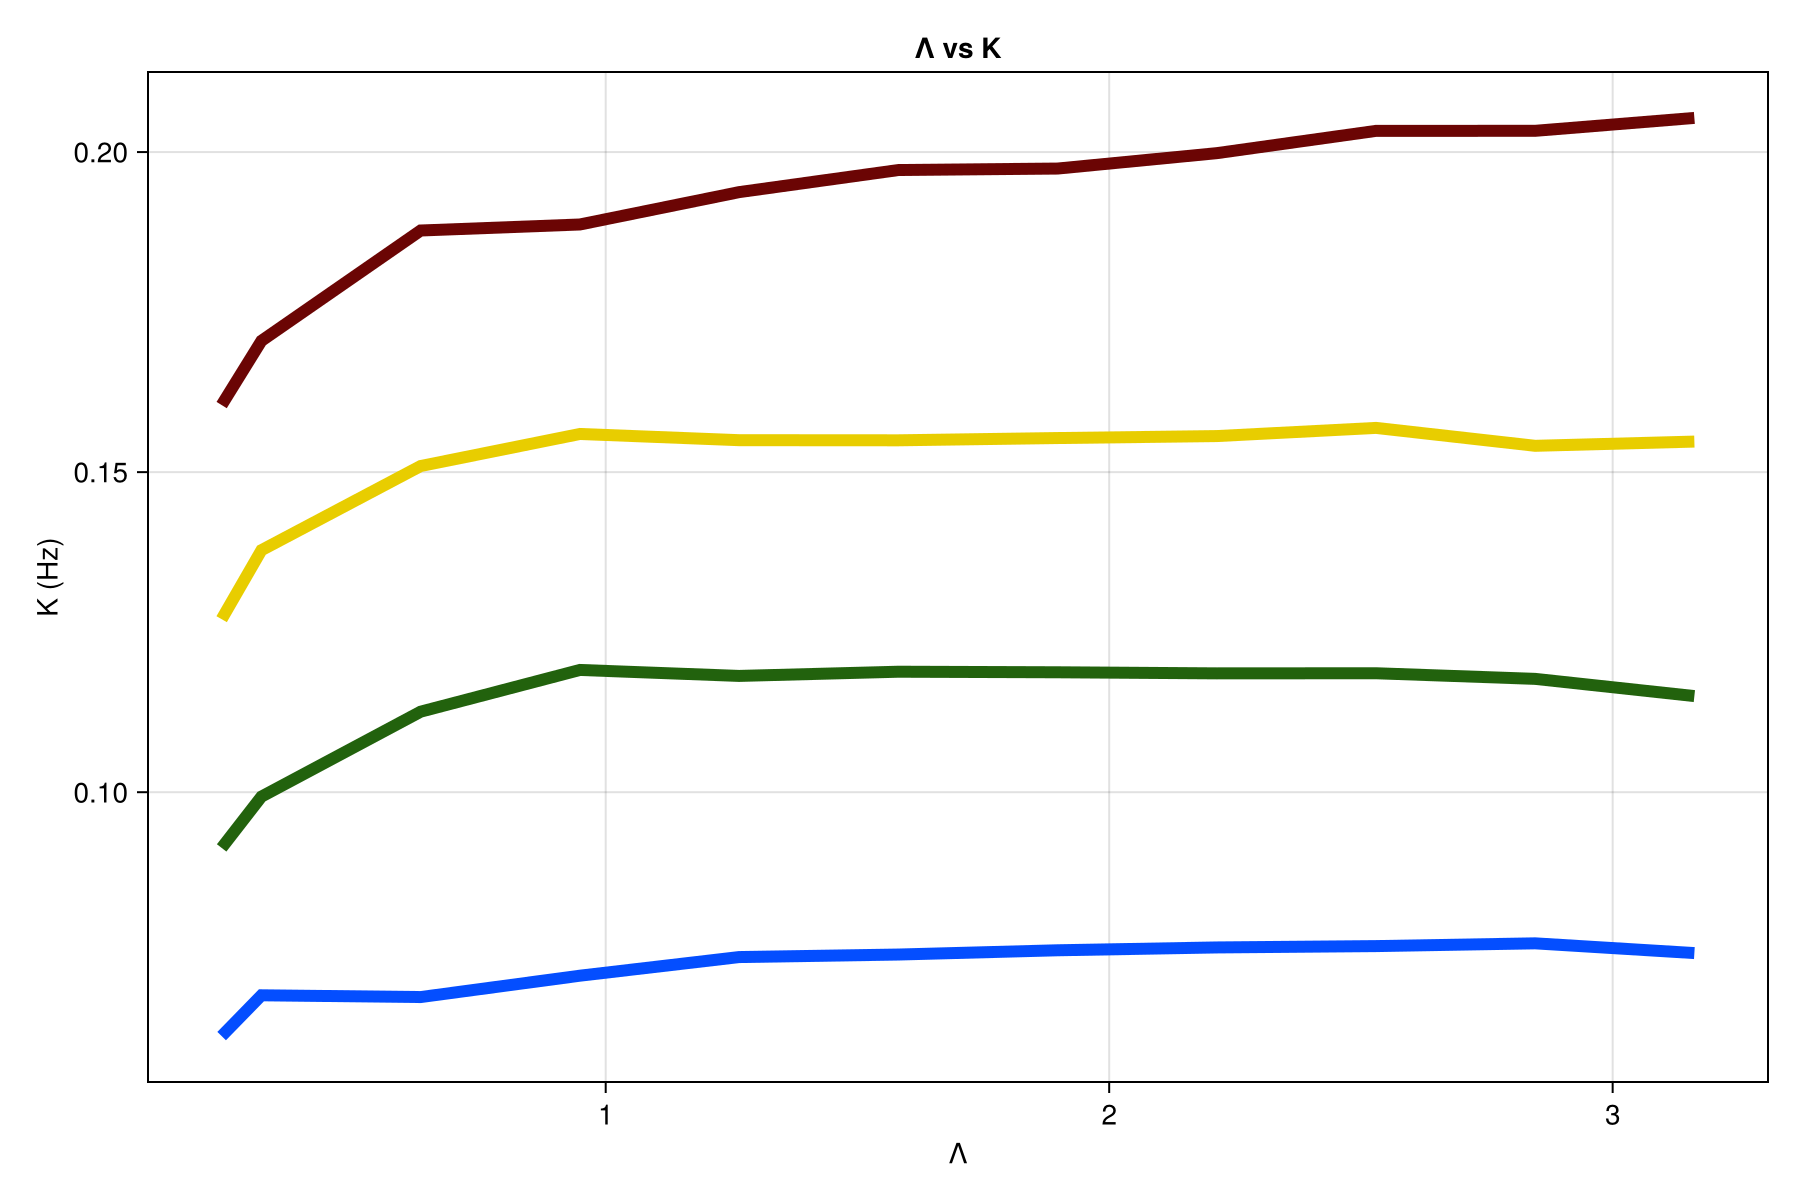

In [141]:
real_lambdas = [0.0790569415, 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766, 4.111, 4.743, 6.325]
lambdas = [ 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 13.0, 15.0, 20.0]

tms = [1.0, 2.0, 4.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]

fig = Figure(size = (900, 600))
# ax_k = Axis(fig[1,1], title = "Λ vs D", xlabel = "Λ", ylabel = "D")
ax_k = Axis(fig[1,1], title = "Λ vs K", xlabel = "Λ", ylabel = "K (Hz)")
# ax_D = Axis(fig[1,2], title = "Λ vs Variance", xlabel = "Λ", ylabel = L"Variance ($\mu m^2$)")
# ax_D = Axis(fig[1,2], title = "Λ vs D", xlabel = "Λ", ylabel = L"D ($\frac{\mu m^2}{s}$)")
# ax_P = Axis(fig[1,1], title = L"P(esc) $\sqrt{\tau _m}$ vs $\Lambda$ ", xlabel = L"log($\Lambda$)", ylabel = L"log (P(esc) $\sqrt{\tau _m}$)")
# ax_P = Axis(fig[1,1], title = "Λ vs P(esc)", xlabel = "Λ", ylabel = "P(esc)")
lambdas_x = real_lambdas[3:end]

tm1_c = colorant"#6B0504"
tm2_c = colorant"#E8CD00"
tm4_c = colorant"#22620D"
tm10_c = colorant"#044EFF"

colors = [tm1_c, tm2_c, tm4_c, tm10_c]
intensity = [0.8, 0.6, 0.4, 0.2]
mean_P_tm = zeros(4, 14)
mean_Ptm = Float64[]

for (idx_t, tm) in enumerate(tms)
        mean_tms_k = zeros(4, 14)
        mean_tms_D = zeros(4, 14)
        mean_tms_P = zeros(4, 14)


    for (idx_v, v) in enumerate(vel)
        k_v = []
        D_v = []
        P_v = []
        v_l = []


        for (idx_l, l) in enumerate(lambdas)
            df = dfs_all[(tm, v, l)]

            filter_1 = metrics_all[metrics_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.l .== l, :]

            # filter_1 = dc_delta_all[dc_delta_all.tm .== tm, :]
            # filter_2 = filter_1[filter_1.v .== v, :]
            # row2 = filter_2[filter_2.n .== l, :]

            # field = row2.l[1]
            k = row.k[1]
            D = row.D[1]
            P_esc = row.P_esc[1]
            # vl = v / field

            push!(k_v, k)
            push!(D_v, D)
            push!(P_v, P_esc)
            # push!(v_l, field)
        end
       
        mean_tms_k[idx_v, :] = k_v
        mean_tms_D[idx_v, :] = D_v
        mean_tms_P[idx_v, :] = P_v



        lines!(ax_P,log.(lambdas_x[3:14]) ,log.(P_v[3:14] .* sqrt(tm)), color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_P,range(-0.5,1),range(-0.5,1), label ="m=1", color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_k, lambdas_x, k_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_D, lambdas_x, D_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_P, lambdas_x, P_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        
        

    end

    mean_k = []
    mean_D = []
    mean_P = []

    for i in 1:length(lambdas)
        push!(mean_k, mean(mean_tms_k[:, i]))
        push!(mean_D, mean(mean_tms_D[:, i]))
        push!(mean_P, mean(mean_tms_P[:, i]))
        
    end

    lines!(ax_k, lambdas_x[1:11], mean_k[1:11], linewidth = 6, label ="$tm", color = colors[idx_t])
    # # lines!(ax_D, lambdas_x, mean_D, linewidth = 6, label ="$tm", color = colors[idx_t])
    # # lines!(ax_P, lambdas_x, mean_P, linewidth = 6, label ="$tm", color = colors[idx_t])
    
    # slope, intercept = linear_fit(log.(lambdas_x[3:14]), log.(mean_P[3:14]))
    # lines!(ax_P, log.(lambdas_x[3:14]), intercept .+  log.(lambdas_x[3:14]) .* slope, linestyle = :dash, color = :red, label = "$slope")
end  

# ax_k.topspinevisible = false
# ax_k.rightspinevisible = false
# ax_k.ygridvisible = false
# ax_k.xgridvisible = false

# ax_D.topspinevisible = false
# ax_D.rightspinevisible = false
# ax_D.ygridvisible = false
# ax_D.xgridvisible = false

ax_P.topspinevisible = false
ax_P.rightspinevisible = false
ax_P.ygridvisible = false
ax_P.xgridvisible = false

# fig[1,2] = Legend(fig, ax_P, "V") # ?

fig            


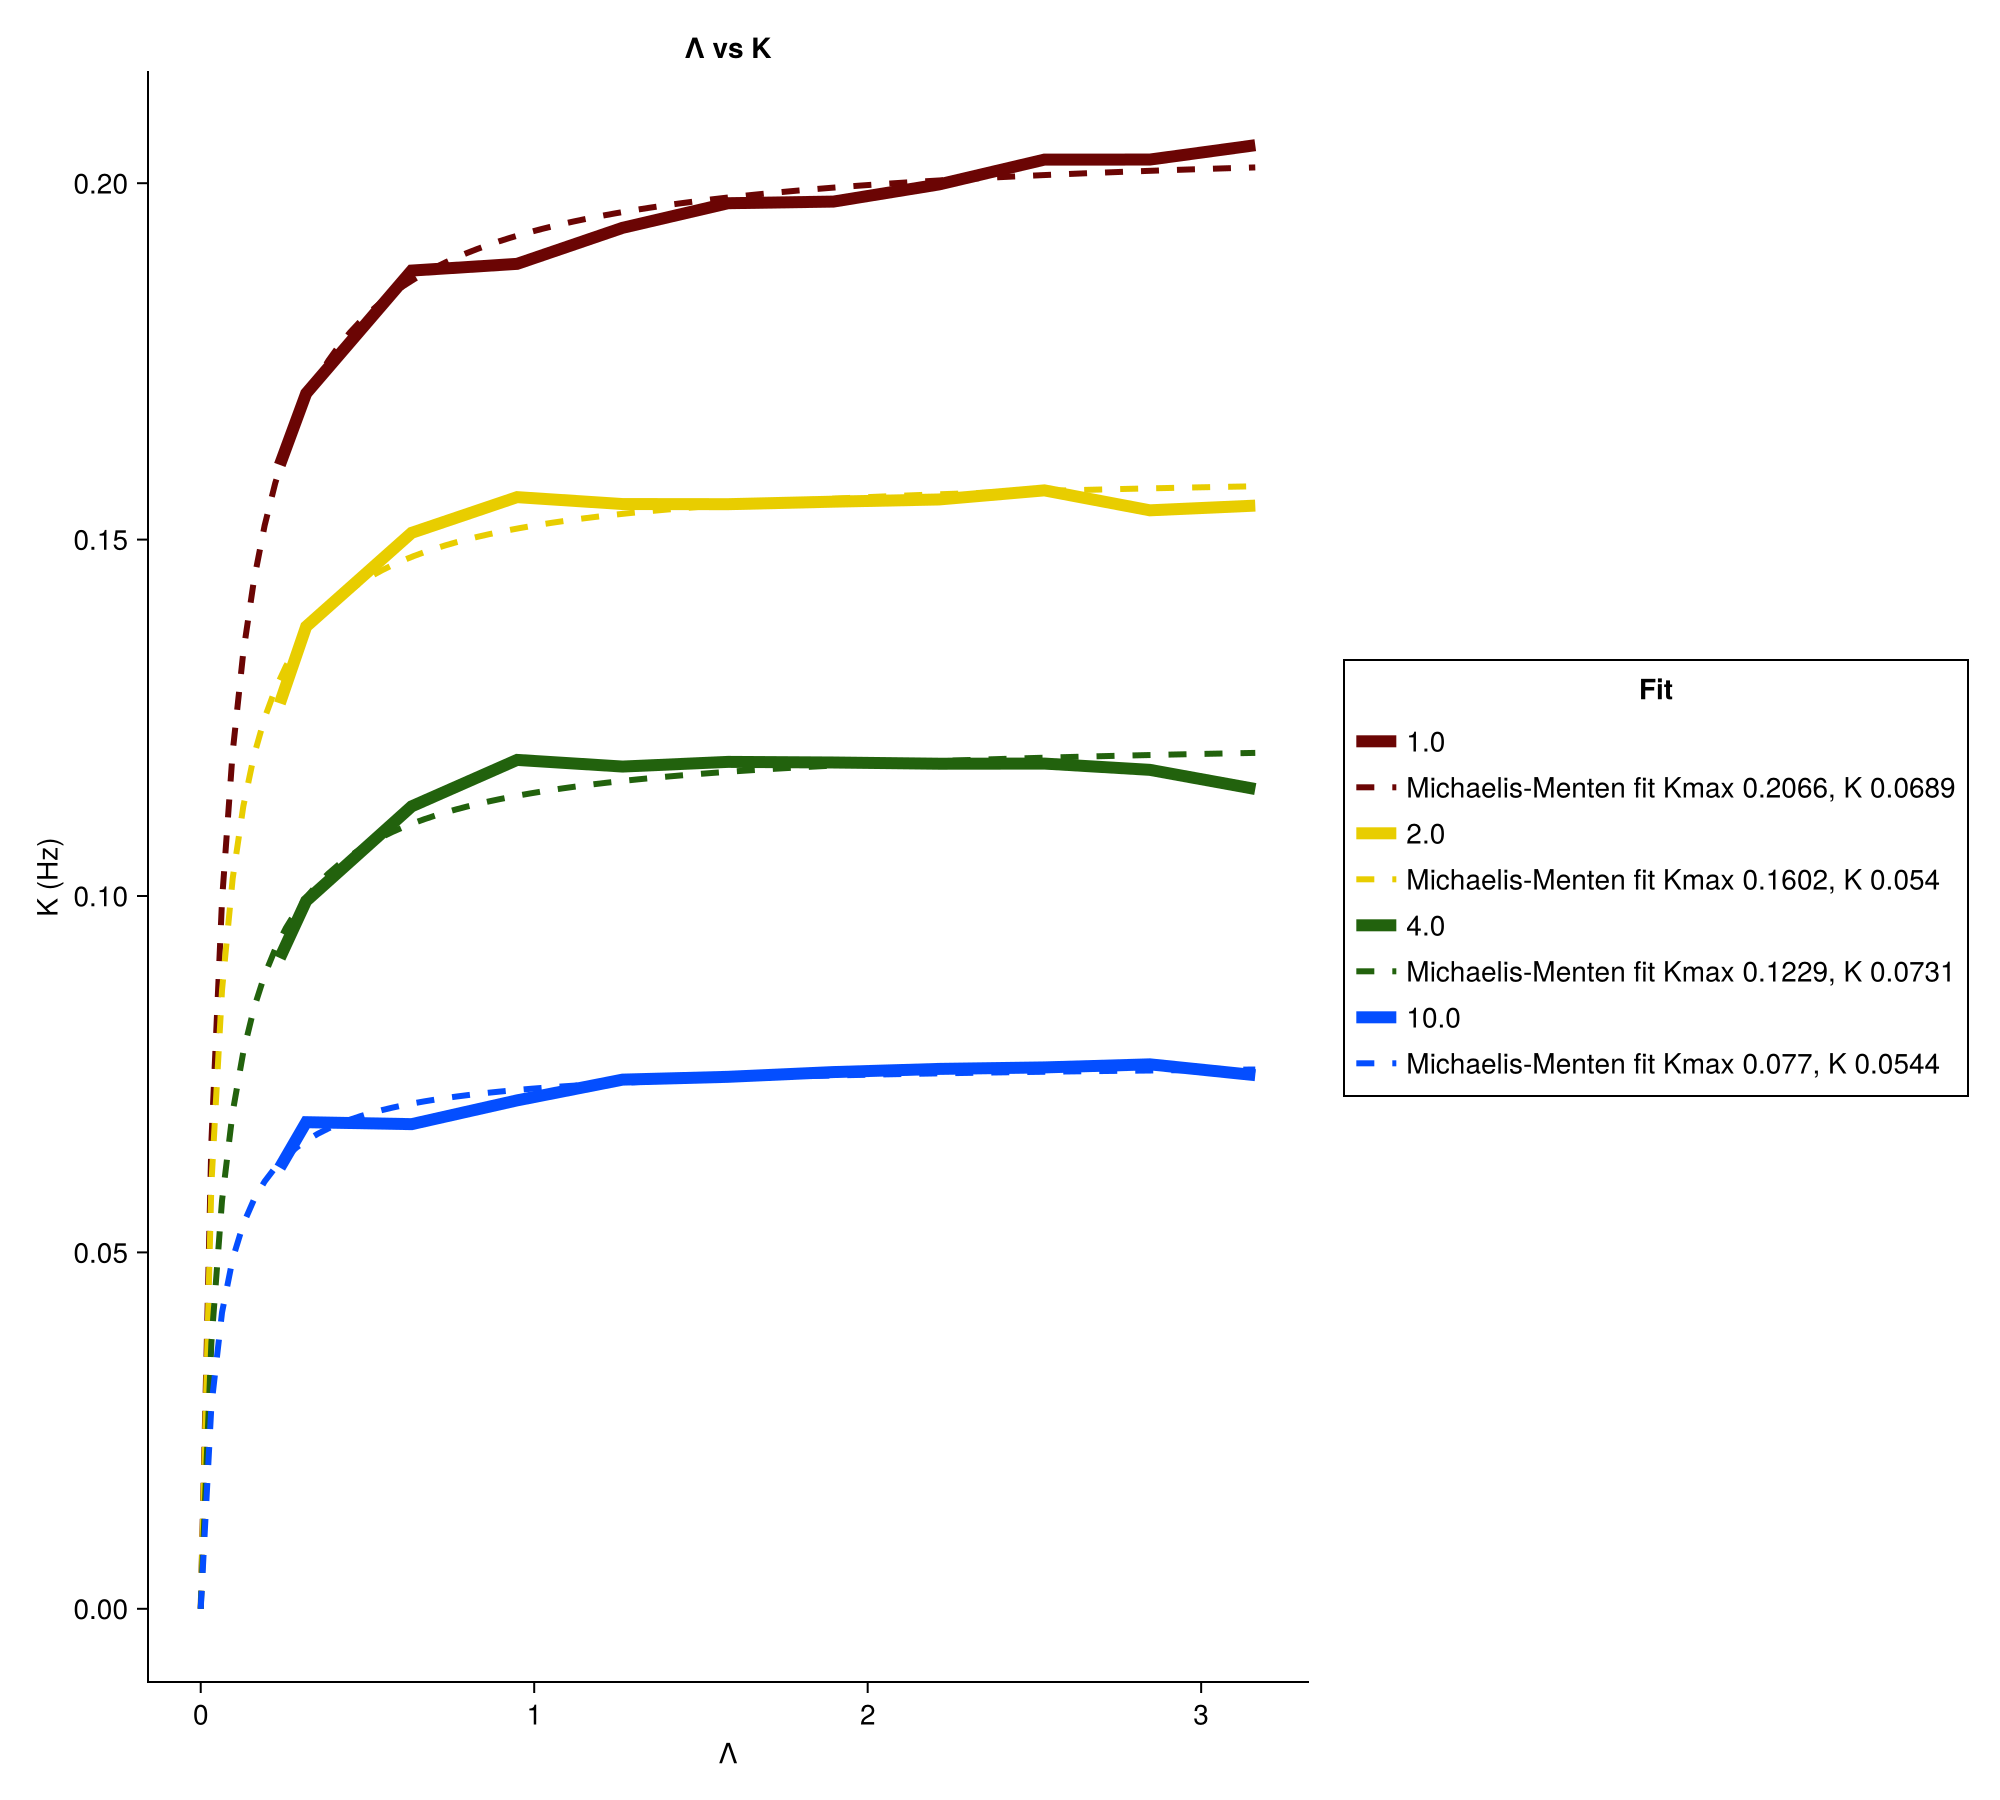

In [168]:
real_lambdas = [0.0790569415, 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766, 4.111, 4.743, 6.325]
lambdas = [ 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 13.0, 15.0, 20.0]

tms = [1.0, 2.0, 4.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]

fig = Figure(size = (1000, 900))
# ax_k = Axis(fig[1,1], title = "Λ vs D", xlabel = "Λ", ylabel = "D")
ax_k = Axis(fig[1,1], title = "Λ vs K", xlabel = "Λ", ylabel = "K (Hz)")
# ax_D = Axis(fig[1,2], title = "Λ vs Variance", xlabel = "Λ", ylabel = L"Variance ($\mu m^2$)")
# ax_D = Axis(fig[1,2], title = "Λ vs D", xlabel = "Λ", ylabel = L"D ($\frac{\mu m^2}{s}$)")
# ax_P = Axis(fig[1,1], title = L"P(esc) $\sqrt{\tau _m}$ vs $\Lambda$ ", xlabel = L"log($\Lambda$)", ylabel = L"log (P(esc) $\sqrt{\tau _m}$)")
# ax_P = Axis(fig[1,1], title = "Λ vs P(esc)", xlabel = "Λ", ylabel = "P(esc)")
lambdas_x = real_lambdas[3:end]

tm1_c = colorant"#6B0504"
tm2_c = colorant"#E8CD00"
tm4_c = colorant"#22620D"
tm10_c = colorant"#044EFF"

colors = [tm1_c, tm2_c, tm4_c, tm10_c]
intensity = [0.8, 0.6, 0.4, 0.2]
mean_P_tm = zeros(4, 14)
mean_Ptm = Float64[]

for (idx_t, tm) in enumerate(tms)
        mean_tms_k = zeros(4, 14)
        mean_tms_D = zeros(4, 14)
        mean_tms_P = zeros(4, 14)


    for (idx_v, v) in enumerate(vel)
        k_v = []
        D_v = []
        P_v = []
        v_l = []


        for (idx_l, l) in enumerate(lambdas)
            df = dfs_all[(tm, v, l)]

            filter_1 = metrics_all[metrics_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.l .== l, :]

            # filter_1 = dc_delta_all[dc_delta_all.tm .== tm, :]
            # filter_2 = filter_1[filter_1.v .== v, :]
            # row2 = filter_2[filter_2.n .== l, :]

            # field = row2.l[1]
            k = row.k[1]
            D = row.D[1]
            P_esc = row.P_esc[1]
            # vl = v / field

            push!(k_v, k)
            push!(D_v, D)
            push!(P_v, P_esc)
            # push!(v_l, field)
        end
       
        mean_tms_k[idx_v, :] = k_v
        mean_tms_D[idx_v, :] = D_v
        mean_tms_P[idx_v, :] = P_v



        lines!(ax_P,log.(lambdas_x[3:14]) ,log.(P_v[3:14] .* sqrt(tm)), color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_P,range(-0.5,1),range(-0.5,1), label ="m=1", color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_k, lambdas_x, k_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_D, lambdas_x, D_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_P, lambdas_x, P_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        
        

    end

    mean_k = []
    mean_D = []
    mean_P = []

    for i in 1:length(lambdas)
        push!(mean_k, mean(mean_tms_k[:, i]))
        push!(mean_D, mean(mean_tms_D[:, i]))
        push!(mean_P, mean(mean_tms_P[:, i]))
        
    end

    lines!(ax_k, lambdas_x[1:11], mean_k[1:11], linewidth = 6, label ="$tm", color = colors[idx_t])
    mm_model(x, p) = p[1] .* x ./ (p[2] .+ x)
    # p[1] = kmax
    # p[2] = K
    xdata = Float64.(lambdas_x[1:11])
    ydata = Float64.(mean_k[1:11])
    p0 = [
        maximum(ydata),   # kmax guess
        median(xdata)     # K guess
    ]

    fit = curve_fit(mm_model, xdata, ydata, p0)

    p = fit.param
    kmax, K = p

    xfit = range(0, maximum(xdata), length=100)
    yfit = mm_model(xfit, p)
    lines!(ax_k, xfit, yfit, linewidth=3, label="Michaelis-Menten fit Kmax $(round(kmax, digits=4)), K $(round(K, digits=4))", linestyle =:dash, color = colors[idx_t])
    # # lines!(ax_D, lambdas_x, mean_D, linewidth = 6, label ="$tm", color = colors[idx_t])
    # # lines!(ax_P, lambdas_x, mean_P, linewidth = 6, label ="$tm", color = colors[idx_t])
    
    # slope, intercept = linear_fit(log.(lambdas_x[3:14]), log.(mean_P[3:14]))
    # lines!(ax_P, log.(lambdas_x[3:14]), intercept .+  log.(lambdas_x[3:14]) .* slope, linestyle = :dash, color = :red, label = "$slope")
end  

ax_k.topspinevisible = false
ax_k.rightspinevisible = false
ax_k.ygridvisible = false
ax_k.xgridvisible = false

# ax_D.topspinevisible = false
# ax_D.rightspinevisible = false
# ax_D.ygridvisible = false
# ax_D.xgridvisible = false

ax_P.topspinevisible = false
ax_P.rightspinevisible = false
ax_P.ygridvisible = false
ax_P.xgridvisible = false

fig[1,2] = Legend(fig, ax_k, "Fit") # ?

fig            

In [169]:
save("Plots/Fixed_source_model/Next/All/log_P_esc_log_Lambda_michaelis_fit_grid_2.pdf", fig)

CairoMakie.Screen{PDF}


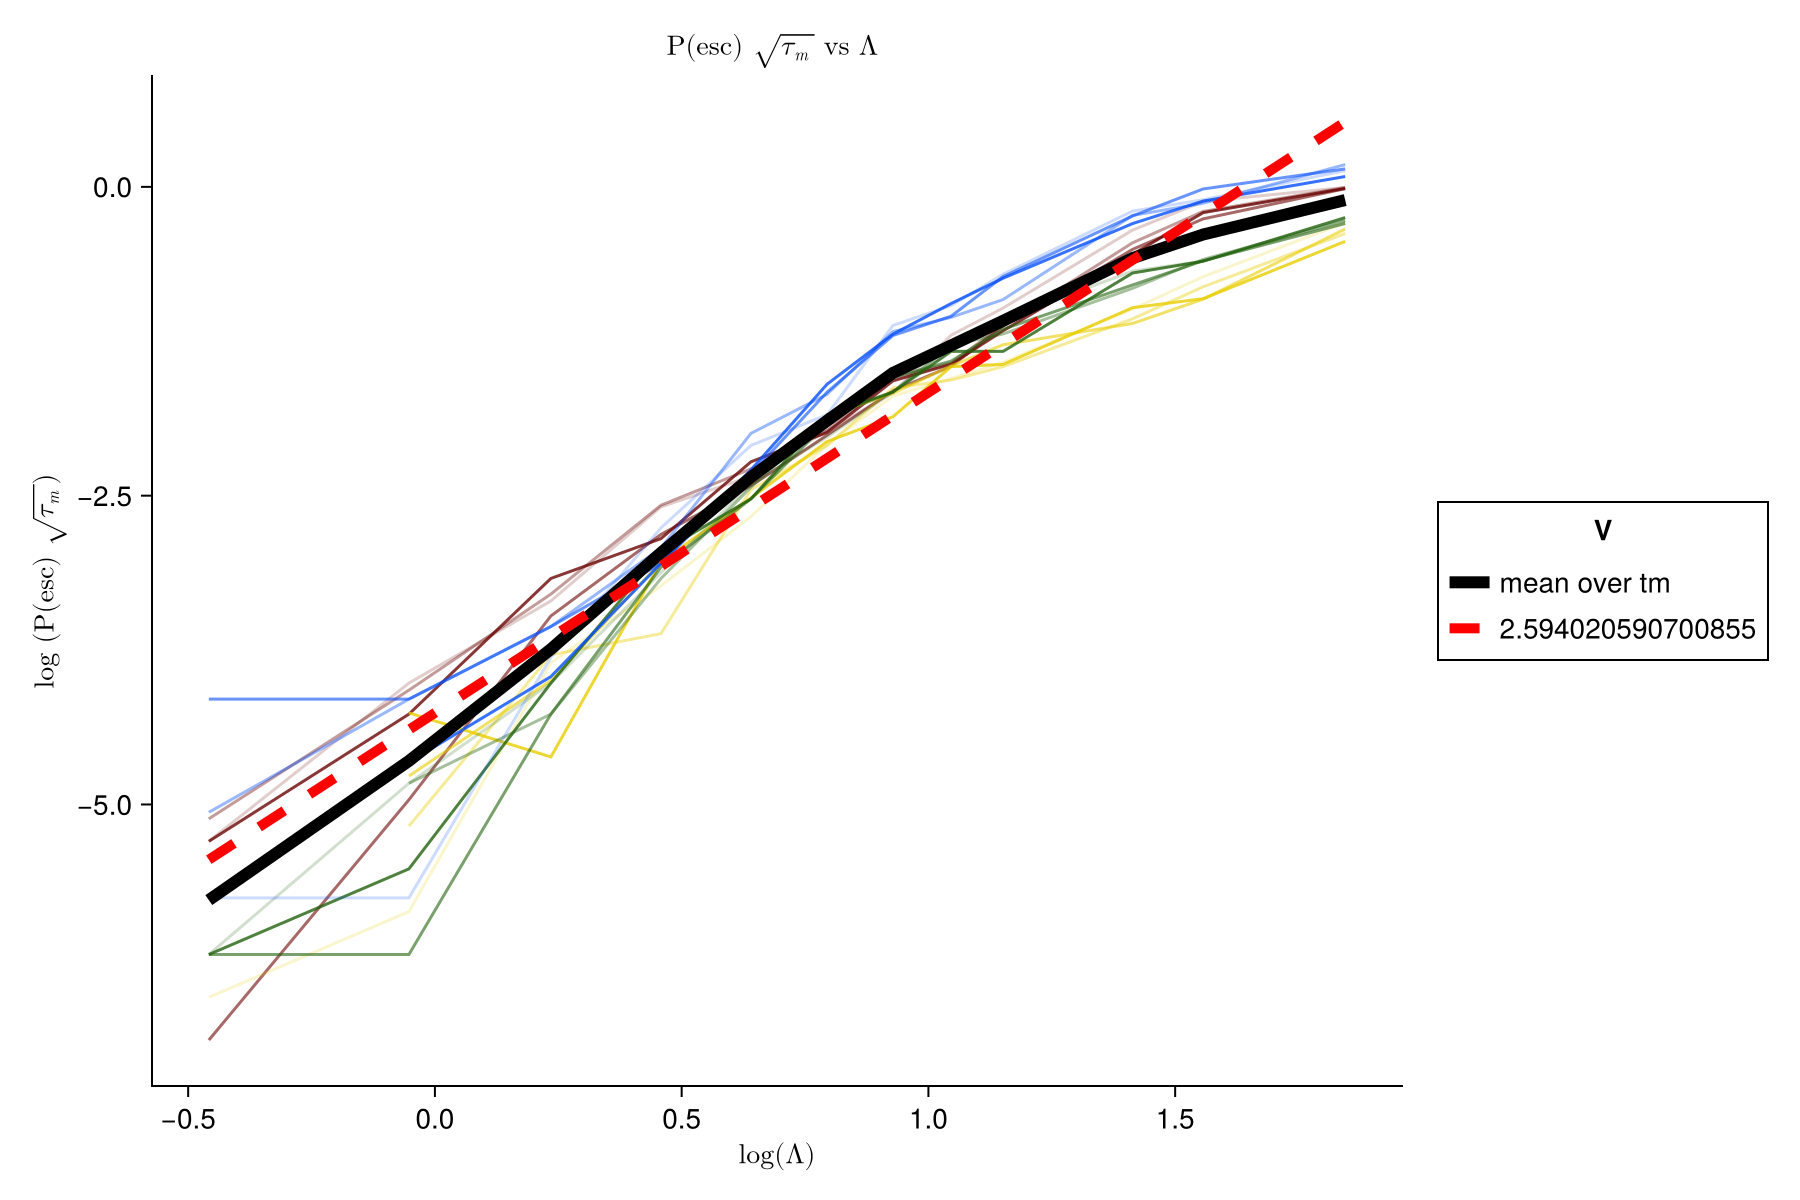

In [131]:
real_lambdas = [0.0790569415, 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766, 4.111, 4.743, 6.325]
lambdas = [0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 13.0, 15.0, 20.0]

tms = [1.0, 2.0, 4.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]

fig = Figure(size = (900, 600))

ax_P = Axis(
    fig[1,1],
    title = L"P(esc) $\sqrt{\tau _m}$ vs $\Lambda$ ",
    xlabel = L"log($\Lambda$)",
    ylabel = L"log (P(esc) $\sqrt{\tau _m}$)"
)

lambdas_x = real_lambdas[3:end]

tm1_c = colorant"#6B0504"
tm2_c = colorant"#E8CD00"
tm4_c = colorant"#22620D"
tm10_c = colorant"#044EFF"

colors = [tm1_c, tm2_c, tm4_c, tm10_c]
intensity = [0.8, 0.6, 0.4, 0.2]

mean_P_tm = zeros(4, 14)
mean_Ptm = Float64[]

# Store the mean_P .* sqrt(tm) curves for each tm
all_mean_P = zeros(length(tms), length(lambdas))

for (idx_t, tm) in enumerate(tms)

    mean_tms_k = zeros(4, 14)
    mean_tms_D = zeros(4, 14)
    mean_tms_P = zeros(4, 14)

    for (idx_v, v) in enumerate(vel)

        k_v = []
        D_v = []
        P_v = []

        for (idx_l, l) in enumerate(lambdas)

            df = dfs_all[(tm, v, l)]

            filter_1 = metrics_all[metrics_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.l .== l, :]

            k = row.k[1]
            D = row.D[1]
            P_esc = row.P_esc[1]

            push!(k_v, k)
            push!(D_v, D)
            push!(P_v, P_esc)
        end

        mean_tms_k[idx_v, :] = k_v
        mean_tms_D[idx_v, :] = D_v
        mean_tms_P[idx_v, :] = P_v

        lines!(
            ax_P,
            log.(lambdas_x[3:14]),
            log.(P_v[3:14] .* sqrt(tm)),
            color = (colors[idx_t], intensity[idx_v])
        )
    end

    mean_k = []
    mean_D = []
    mean_P = []

    for i in 1:length(lambdas)
        push!(mean_k, mean(mean_tms_k[:, i]))
        push!(mean_D, mean(mean_tms_D[:, i]))
        push!(mean_P, mean(mean_tms_P[:, i]))
    end

    # Store the same quantity that is plotted: mean_P * sqrt(tm)
    all_mean_P[idx_t, :] = mean_P .* sqrt(tm)

    # lines!(
    #     ax_P,
    #     log.(lambdas_x[3:14]),
    #     log.(mean_P[3:14] .* sqrt(tm)),
    #     linewidth = 6,
    #     label = "$tm",
    #     color = colors[idx_t]
    # )

    # slope, intercept = linear_fit(
    #     log.(lambdas_x[3:14]),
    #     log.(mean_P[3:14] .* sqrt(tm))
    # )

    # lines!(
    #     ax_P,
    #     log.(lambdas_x[3:14]),
    #     intercept .+ log.(lambdas_x[3:14]) .* slope,
    #     linestyle = :dash,
    #     color = :red,
    #     label = "$slope"
    # )
end

# Mean over all tm values
grand_mean_P = vec(mean(all_mean_P, dims = 1))
slope, intercept = linear_fit(log.(lambdas_x[3:14]), log.(grand_mean_P[3:14]))
lines!(
    ax_P,
    log.(lambdas_x[3:14]),
    log.(grand_mean_P[3:14]),
    linewidth = 6,
    color = :black,
    label = "mean over tm"
)

lines!(
    ax_P,
    log.(lambdas_x[3:14]),
    intercept .+ log.(lambdas_x[3:14]) .* slope,
    linewidth = 5,
    color = :red,
    linestyle = :dash,
    label = "$slope"
)

ax_P.topspinevisible = false
ax_P.rightspinevisible = false
ax_P.ygridvisible = false
ax_P.xgridvisible = false

fig[1,2] = Legend(fig, ax_P, "V")

fig

In [132]:
save("Plots/Fixed_source_model/Next/All/log_P_esc_log_Lambda_slope_all.pdf", fig)


CairoMakie.Screen{PDF}


In [122]:
sort(metrics_all.D)[1:20]

20-element Vector{Float64}:
 10.62134493294639
 14.398144552666084
 14.875781907571557
 15.555049604149932
 15.557002133980088
 16.43963953278096
 17.027724567745693
 17.61516921516367
 19.282990486204394
 19.88801212321901
 20.85126191668872
 20.916177937322477
 21.154452274914764
 23.359988062312787
 23.720819061042853
 24.69782973131797
 25.873083694687672
 27.3455626105354
 28.402686660583313
 28.42894793621545

# D = v^2 tm

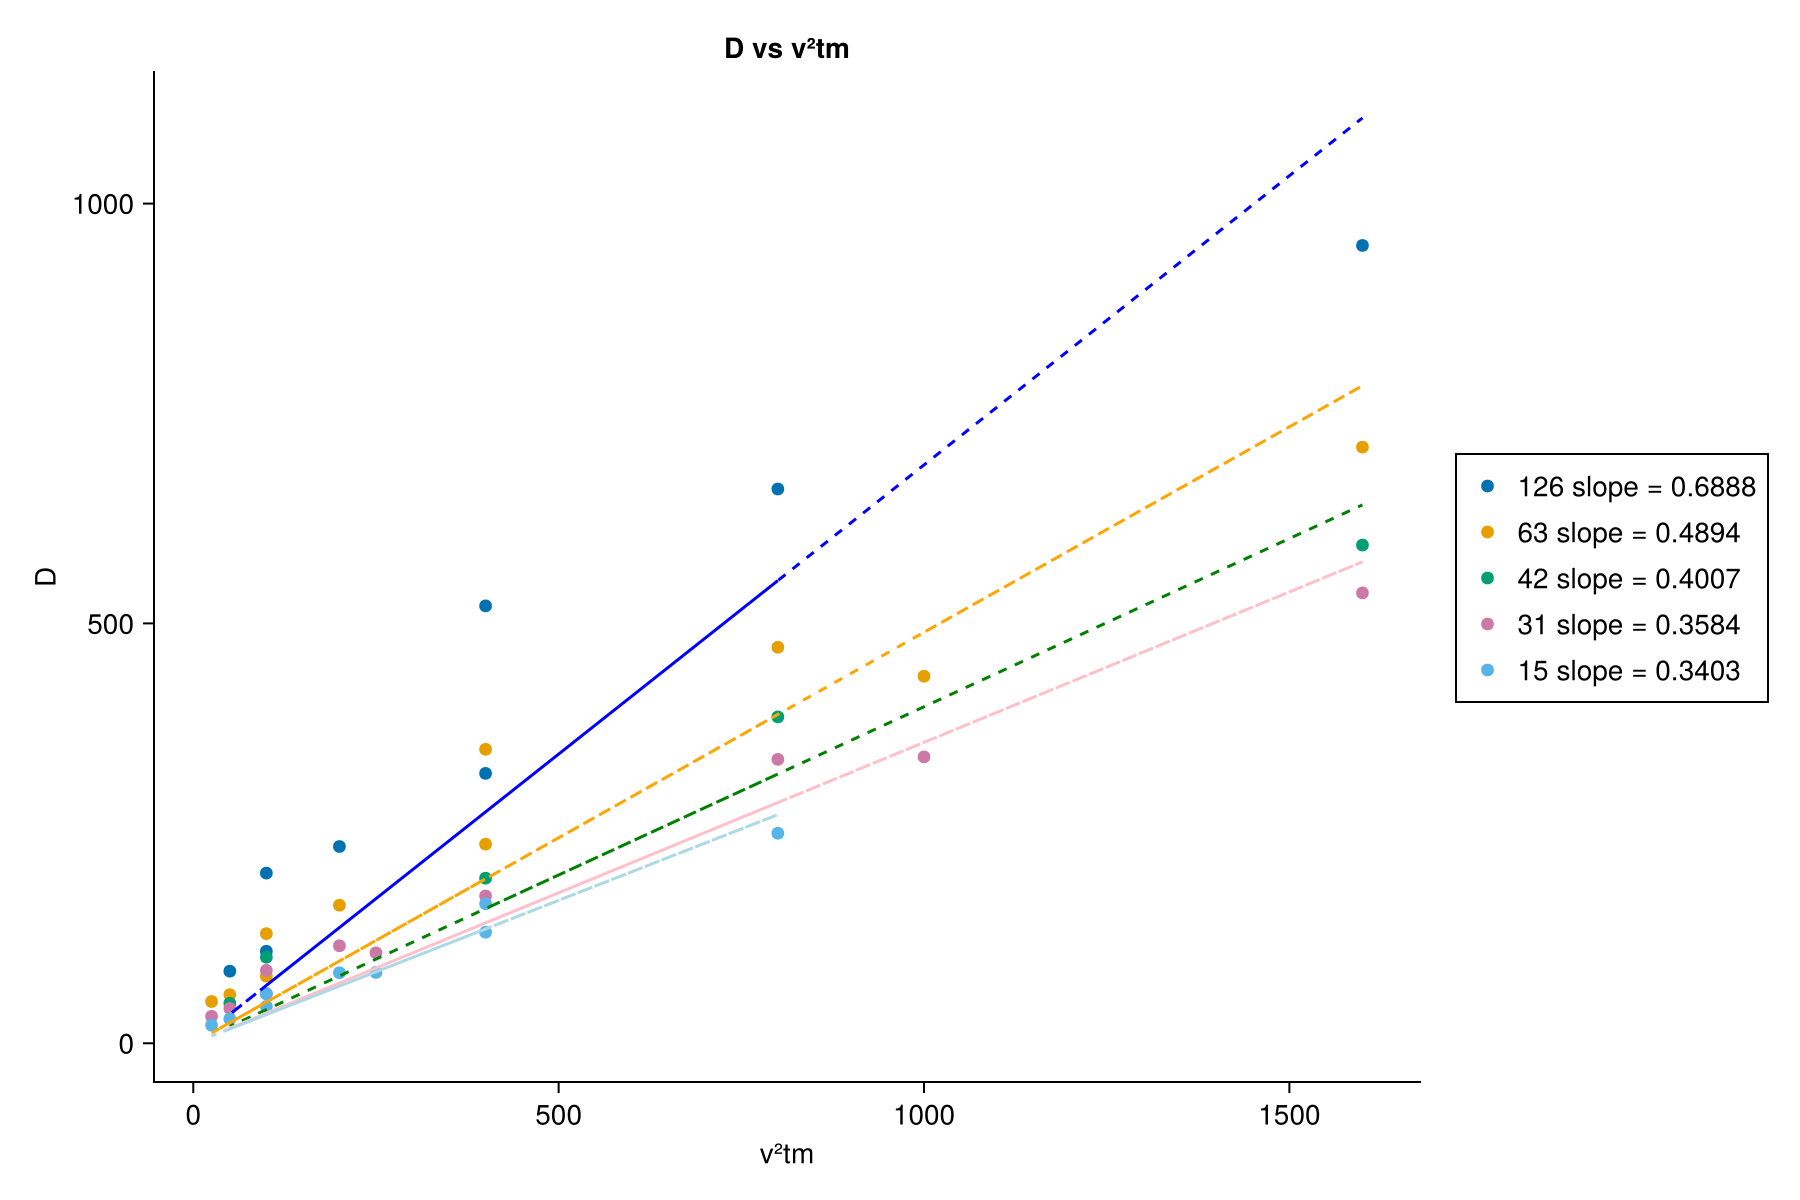

In [144]:
using CairoMakie

selected_126 = [
    (1.0, 10.0, 0.25),
    (1.0, 20.0, 0.5),
    (2.0, 10.0, 0.5),
    (2.0, 5.0, 0.25),
    (2.0, 20.0, 1.0),
    # (2.0, 100.0, 5.0),
    (4.0, 10.0, 1.0),
    (4.0, 5.0, 0.5),
    (4.0, 20.0, 2.0),
    # (4.0, 100.0, 10.0),
    # (10.0, 20.0, 5.0)
]

selected_63 = [
    (1.0, 10.0, 0.5),
    (1.0, 5.0, 0.25),
    (1.0, 20.0, 1.0),
    # (1.0, 100.0, 5.0),
    (2.0, 10.0, 1.0),
    (2.0, 5.0, 0.5),
    (2.0, 20.0, 2.0),
    # (2.0, 100.0, 10.0),
    (4.0, 10.0, 2.0),
    (4.0, 5.0, 1.0),
    (4.0, 20.0, 4.0),
    (10.0, 10.0, 5.0),
    # (10.0, 20.0, 10.0)
]

selected_42 = [
    (1.0, 10.0, 0.75),
    (2.0, 5.0, 0.75),
    (2.0, 20.0, 3.0),
    (4.0, 10.0, 3.0),
    (4.0, 20.0, 6.0)
]
selected_31 = [
    (1.0, 10.0, 1.0),
    (1.0, 5.0, 0.5),
    # (1.0, 100.0, 10.0),
    (2.0, 10.0, 2.0),
    (2.0, 5.0, 1.0),
    (2.0, 20.0, 4.0),
    (4.0, 10.0, 4.0),
    (4.0, 5.0, 2.0),
    (4.0, 20.0, 8.0),
    (10.0, 10.0, 10.0),
    (10.0, 5.0, 5.0)
]
selected_15 = [
    (1.0, 10.0, 2.0),
    (1.0, 5.0, 1.0),
    (1.0, 20.0, 4.0),
    (2.0, 10.0, 4.0),
    (2.0, 5.0, 2.0),
    (2.0, 20.0, 8.0),
    (4.0, 10.0, 8.0),
    (4.0, 5.0, 4.0),
    (10.0, 5.0, 10.0)
]


vtm_126 = Float64[]
diff_126 = Float64[]
vtm_63 = Float64[]
diff_63 = Float64[]
vtm_42 = Float64[]
diff_42 = Float64[]
vtm_31 = Float64[]
diff_31 = Float64[]
vtm_15 = Float64[]
diff_15 = Float64[]

for (tm, v, n) in selected_126

    mask = (metrics_all.tm .== tm) .&
           (metrics_all.v  .== v)  .&
           (metrics_all.l  .== n)

    row = metrics_all[mask, :]

    if nrow(row) == 0
        @warn "No match for ($tm, $v, $n)"
        continue
    end

    D = row.variance[1]   # replace variance by the correct D column if needed

    push!(vtm_126, v^2 * tm)
    push!(diff_126, D)
end
for (tm, v, n) in selected_63

    mask = (metrics_all.tm .== tm) .&
           (metrics_all.v  .== v)  .&
           (metrics_all.l  .== n)

    row = metrics_all[mask, :]

    if nrow(row) == 0
        @warn "No match for ($tm, $v, $n)"
        continue
    end

    D = row.variance[1]   # replace variance by the correct D column if needed

    push!(vtm_63, v^2 * tm)
    push!(diff_63, D)
end
for (tm, v, n) in selected_42

    mask = (metrics_all.tm .== tm) .&
           (metrics_all.v  .== v)  .&
           (metrics_all.l  .== n)

    row = metrics_all[mask, :]

    if nrow(row) == 0
        @warn "No match for ($tm, $v, $n)"
        continue
    end

    D = row.variance[1]   # replace variance by the correct D column if needed

    push!(vtm_42, v^2 * tm)
    push!(diff_42, D)
end

for (tm, v, n) in selected_31

    mask = (metrics_all.tm .== tm) .&
           (metrics_all.v  .== v)  .&
           (metrics_all.l  .== n)

    row = metrics_all[mask, :]

    if nrow(row) == 0
        @warn "No match for ($tm, $v, $n)"
        continue
    end

    D = row.variance[1]   # replace variance by the correct D column if needed

    push!(vtm_31, v^2 * tm)
    push!(diff_31, D)
end

for (tm, v, n) in selected_15

    mask = (metrics_all.tm .== tm) .&
           (metrics_all.v  .== v)  .&
           (metrics_all.l  .== n)

    row = metrics_all[mask, :]

    if nrow(row) == 0
        @warn "No match for ($tm, $v, $n)"
        continue
    end

    D = row.variance[1]   # replace variance by the correct D column if needed

    push!(vtm_15, v^2 * tm)
    push!(diff_15, D)
end


fig = Figure(size = (900, 600))
ax = Axis(
    fig[1,1],
    title = "D vs v²tm",
    xlabel = "v²tm",
    ylabel = "D"
)

# scatter!(ax, vtm, diff)
slope_126 = linear_fit_mx(vtm_126, diff_126)
slope_63 = linear_fit_mx(vtm_63, diff_63)
slope_42 = linear_fit_mx(vtm_42, diff_42)
slope_31 = linear_fit_mx(vtm_31, diff_31)
slope_15 = linear_fit_mx(vtm_15, diff_15)

scatter!(ax, vtm_126, diff_126, label = "126 slope = $(round(slope_126, digits=4))")
scatter!(ax, vtm_63, diff_63, label = "63 slope = $(round(slope_63, digits=4))")
scatter!(ax, vtm_42, diff_42, label = "42 slope = $(round(slope_42, digits=4))")
scatter!(ax, vtm_31, diff_31, label = "31 slope = $(round(slope_31, digits=4))")
scatter!(ax, vtm_15, diff_15, label = "15 slope = $(round(slope_15, digits=4))")

lines!(ax, vtm_126, slope_126 .* vtm_126 ,linestyle = :dash, color = :blue)
lines!(ax, vtm_63, slope_63 .* vtm_63 ,linestyle = :dash, color = :orange)
lines!(ax, vtm_42, slope_42 .* vtm_42 ,linestyle = :dash, color = :green)
lines!(ax, vtm_31, slope_31 .* vtm_31 ,linestyle = :dash, color = :pink)
lines!(ax, vtm_15, slope_15 .* vtm_15 ,linestyle = :dash, color = :lightblue)

ax.topspinevisible = false
ax.rightspinevisible = false
ax.ygridvisible = false
ax.xgridvisible = false

fig[1,2] = Legend(fig, ax)
fig

In [70]:
save("Plots/Fixed_source_model/Next/d_vtm_l_grid.pdf", fig)

CairoMakie.Screen{PDF}


In [64]:
function linear_fit(x, y)
    """Simple linear regression: y = a + b*x"""
    n = length(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_xy = sum(x .* y)
    sum_x2 = sum(x.^2)
    
    slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x^2)
    intercept = (sum_y - slope * sum_x) / n
    
    return slope, intercept
end

linear_fit (generic function with 1 method)

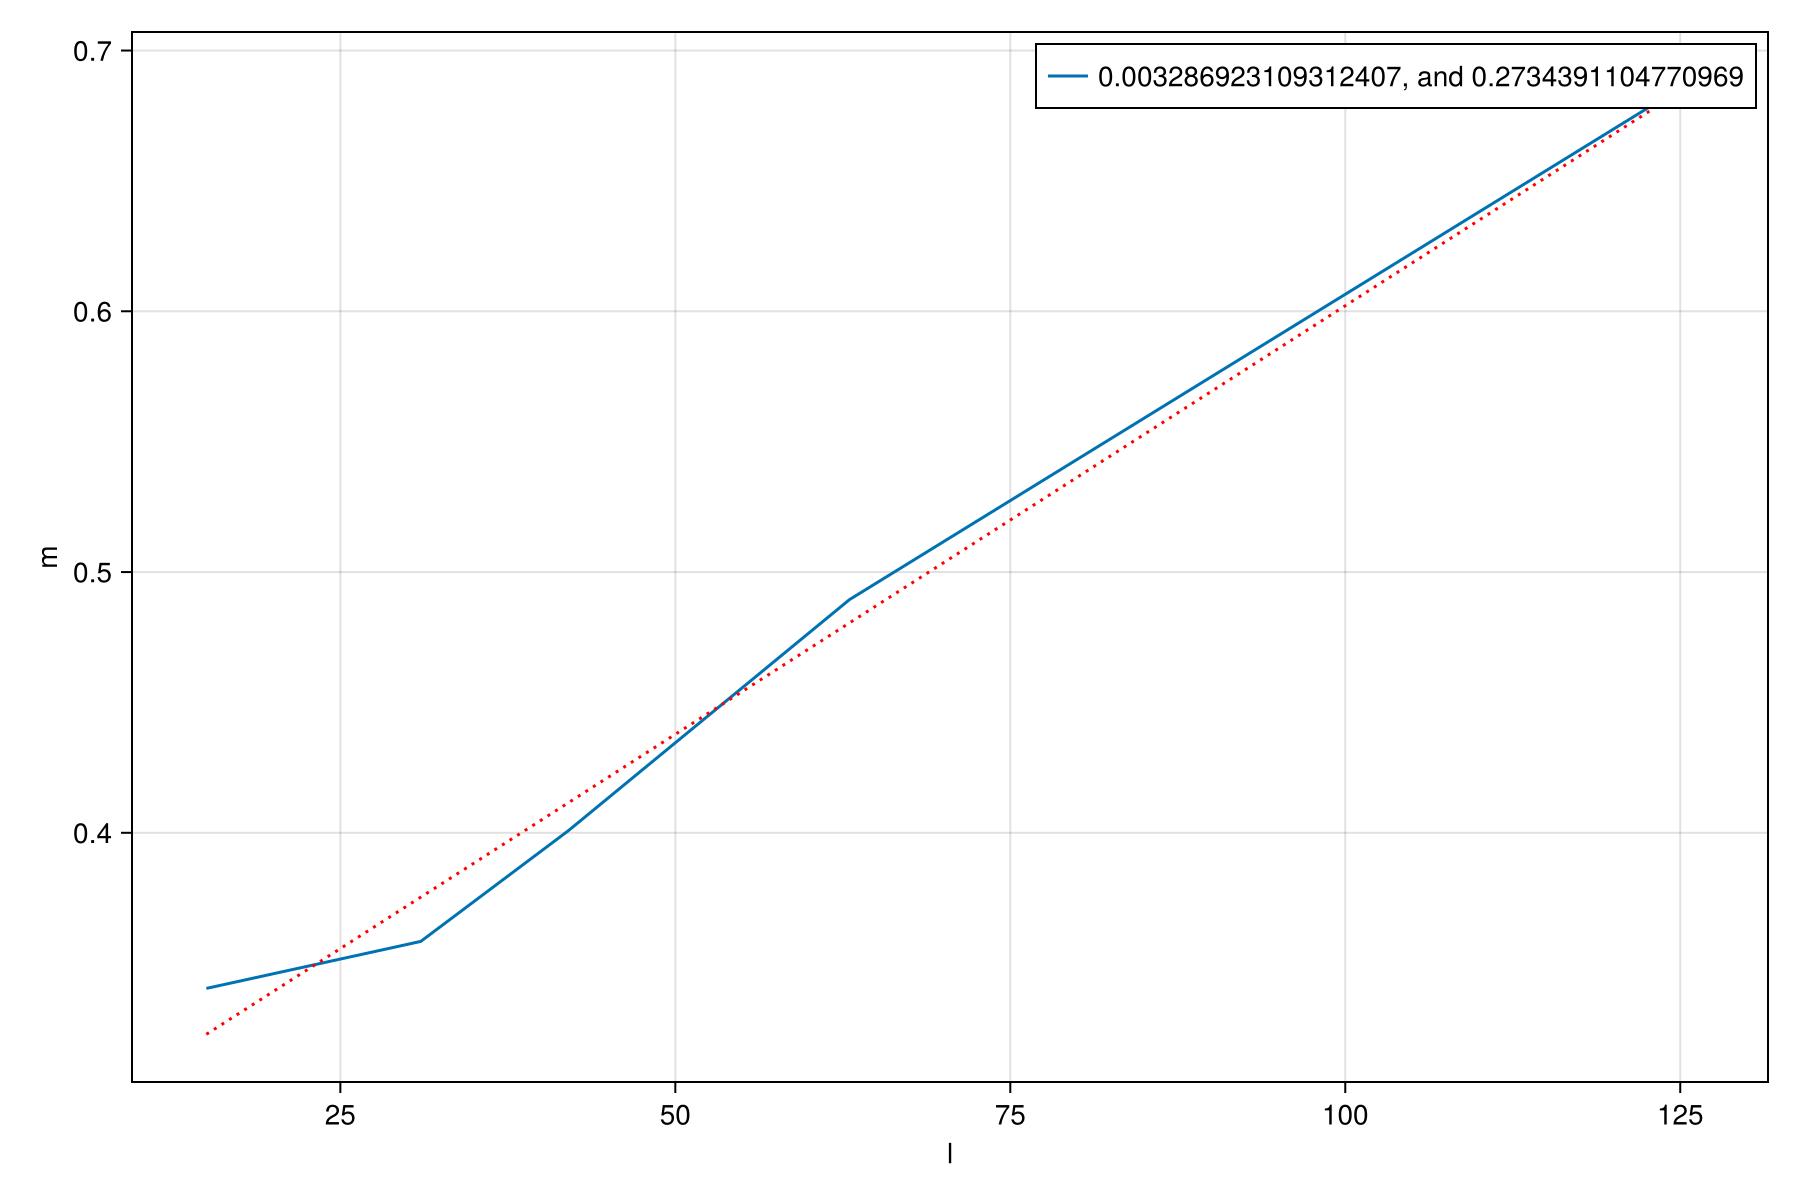

In [145]:
fig = Figure(size=(900, 600))
ax = Axis(fig[1,1], xlabel = "l", ylabel = "m")
m = [slope_15, slope_31, slope_42, slope_63, slope_126]
l =  [15, 31, 42, 63, 126]
slope_lm, intercept = linear_fit(l, m)
lines!(ax, l, m, label ="$slope_lm, and $intercept")
lines!(ax, l, intercept .+ l .* slope_lm, linestyle = :dot, color = :red)
axislegend(ax)
fig

In [76]:
save("Plots/Fixed_source_model/Nextl_m_slope.pdf", fig)

CairoMakie.Screen{PDF}


In [130]:
sort(metrics_all.k)

252-element Vector{Float64}:
 0.4114055583209632
 0.438094756971233
 0.4531989397352447
 0.5575777979005639
 0.588733683086778
 0.607739152574746
 0.6247367476983707
 0.626798879289739
 0.6524463828888039
 0.6546449694796077
 ⋮
 2.172150874287995
 2.1842000259490697
 2.194525545401695
 2.206443589270072
 2.2091003649278025
 2.2702036135213683
 2.2815238210391686
 2.308767841890962
 2.3138658787955837